# NeuroVision-X

## Deep Artificial Neural Network From Scratch for Multi-Class Brain MRI Classification

### Author
Raj Halwai

---

### Objective

To build a Deep Artificial Neural Network completely from scratch using NumPy for classifying Brain MRI images into four disease categories.

### Dataset

- Glioma
- Meningioma
- Pituitary
- No Tumor

### Technologies

- Python
- NumPy
- OpenCV
- Matplotlib
- Pandas
- Scikit-Learn

### Deep Learning Frameworks Used

None

Everything is implemented mathematically from scratch.

In [1]:
import os
import cv2
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, label_binarize

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/AI - PROJECTS/NeuroVision-X"

TRAIN_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Testing"

IMAGE_SIZE = 64

CLASSES = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

In [4]:
# Dataset Statistics

train_info = {}
test_info = {}

train_total = 0
test_total = 0

print("========== TRAINING DATA ==========\n")

for cls in CLASSES:
    folder = os.path.join(TRAIN_PATH, cls)
    count = len(os.listdir(folder))
    train_info[cls] = count
    train_total += count
    print(f"{cls} : {count}")

print("\nTotal Training Images :", train_total)
print("\n")
print("========== TESTING DATA ==========\n")

for cls in CLASSES:
    folder = os.path.join(TEST_PATH, cls)
    count = len(os.listdir(folder))
    test_info[cls] = count
    test_total += count
    print(f"{cls} : {count}")

print("\nTotal Testing Images :", test_total)
print("\nGrand Total Images :", train_total + test_total)

========== TRAINING DATA ==========

glioma : 1400
meningioma : 1400
pituitary : 1400
notumor : 1400

Total Training Images : 5600


========== TESTING DATA ==========

glioma : 400
meningioma : 400
pituitary : 400
notumor : 400

Total Testing Images : 1600

Grand Total Images : 7200


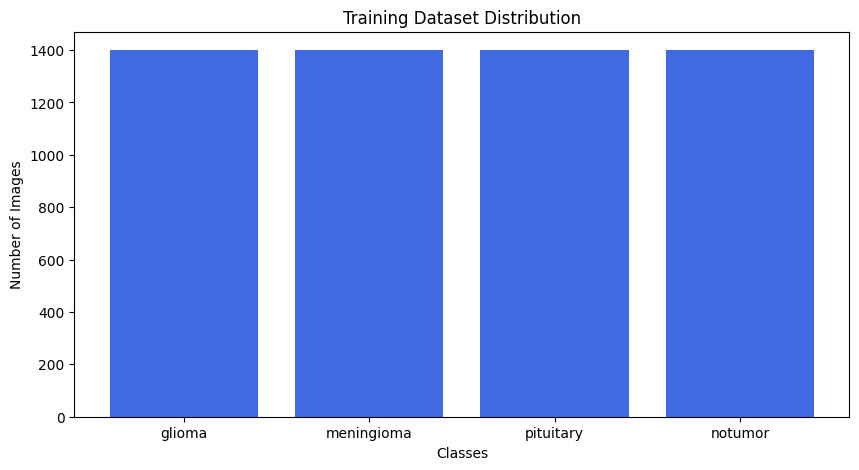

In [5]:
plt.figure(figsize=(10,5))

plt.bar(
    train_info.keys(),
    train_info.values(),
    color="royalblue"
)

plt.title("Training Dataset Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [6]:
import os

print(os.listdir(DATASET_PATH))

['Testing', 'Training']


In [7]:
print(os.listdir(TRAIN_PATH))

['glioma', 'meningioma', 'pituitary', 'notumor']


In [8]:
#load training and testing images
# Load Dataset

X_train = []
y_train = []

X_test = []
y_test = []

print("Loading Training Images...")

for label, cls in enumerate(CLASSES):

    folder = os.path.join(TRAIN_PATH, cls)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

        image = image.astype(np.float32) / 255.0

        X_train.append(image)

        y_train.append(label)

print("Loading Testing Images...")

for label, cls in enumerate(CLASSES):

    folder = os.path.join(TEST_PATH, cls)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

        image = image.astype(np.float32) / 255.0

        X_test.append(image)

        y_test.append(label)

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Loading Training Images...
Loading Testing Images...
Training Images : (5600, 64, 64, 3)
Testing Images  : (1600, 64, 64, 3)


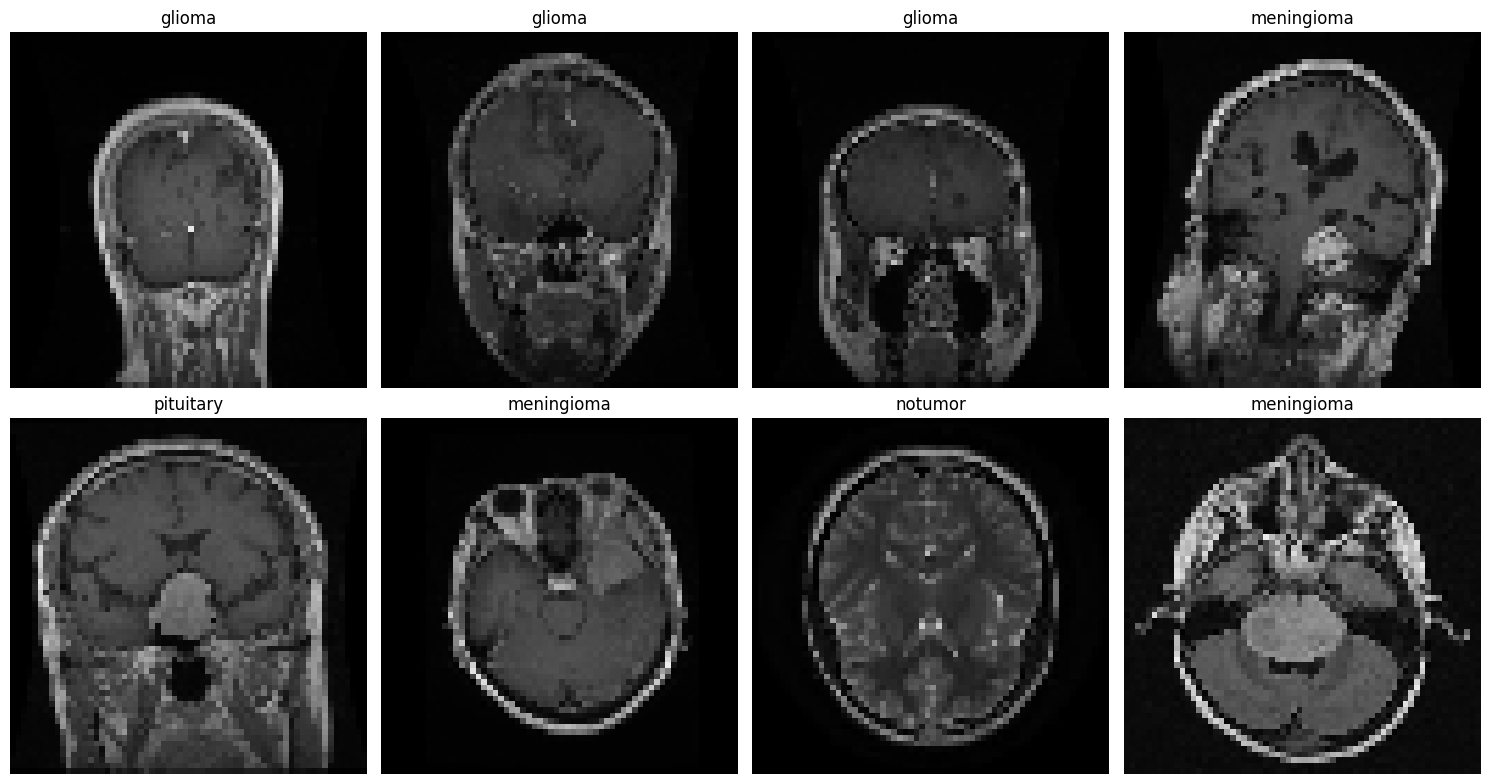

In [9]:
#Visualize Random Images
plt.figure(figsize=(15,8))

for i in range(8):

    idx = random.randint(0, len(X_train)-1)

    plt.subplot(2,4,i+1)

    plt.imshow(X_train[idx])

    plt.title(CLASSES[y_train[idx]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [10]:
#Flatten Images : Our ANN accepts vectors, not 3D images.
X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

print("Flattened Training Shape :", X_train.shape)
print("Flattened Testing Shape  :", X_test.shape)

Flattened Training Shape : (5600, 12288)
Flattened Testing Shape  : (1600, 12288)


In [11]:
#One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

print(y_train.shape)
print(y_test.shape)

(5600, 4)
(1600, 4)


In [12]:
#Create Validation Set
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

Training : (4480, 12288)
Validation : (1120, 12288)
Testing : (1600, 12288)


In [13]:
# Parameter Initialization

def initialize_parameters(input_size):
    params = {}

    params["W1"] = np.random.randn(input_size, 1024) * np.sqrt(2 / input_size)
    params["b1"] = np.zeros((1, 1024))

    params["W2"] = np.random.randn(1024, 512) * np.sqrt(2 / 1024)
    params["b2"] = np.zeros((1, 512))

    params["W3"] = np.random.randn(512, 256) * np.sqrt(2 / 512)
    params["b3"] = np.zeros((1, 256))

    params["W4"] = np.random.randn(256, 4) * np.sqrt(2 / 256)
    params["b4"] = np.zeros((1, 4))

    return params

In [14]:
#ReLU
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(np.float32)

In [15]:
#Softmax
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    exp = np.exp(Z)
    return exp / np.sum(exp, axis=1, keepdims=True)

In [17]:
#Forward Propagation
def forward_propagation(X, params):

    Z1 = np.dot(X, params["W1"]) + params["b1"]
    A1 = relu(Z1)

    Z2 = np.dot(A1, params["W2"]) + params["b2"]
    A2 = relu(Z2)

    Z3 = np.dot(A2, params["W3"]) + params["b3"]
    A3 = relu(Z3)

    Z4 = np.dot(A3, params["W4"]) + params["b4"]
    A4 = softmax(Z4)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3,
        "Z4": Z4,
        "A4": A4
    }

    return A4, cache

In [18]:
#Cross Entropy Loss + L2
def compute_loss(
    Y,
    predictions,
    params,
    lambda_reg=0.0005
):

    m = Y.shape[0]
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    cross_entropy = -np.sum(Y * np.log(predictions)) / m

    l2 = 0

    for i in range(1,5):
        l2 += np.sum(
            np.square(
                params[f"W{i}"]
            )
        )

    l2 = (lambda_reg / (2*m)) * l2
    return cross_entropy + l2

In [19]:
#Initialize Model
params = initialize_parameters(
    X_train.shape[1]
)

print("Model Initialized Successfully")

for key in params:

    print(key, params[key].shape)

Model Initialized Successfully
W1 (12288, 1024)
b1 (1, 1024)
W2 (1024, 512)
b2 (1, 512)
W3 (512, 256)
b3 (1, 256)
W4 (256, 4)
b4 (1, 4)


In [20]:
#Test Forward Propagation
predictions, cache = forward_propagation(
    X_train[:32],
    params
)

loss = compute_loss(
    y_train[:32],
    predictions,
    params
)

print("Prediction Shape :", predictions.shape)

print("Loss :", loss)

Prediction Shape : (32, 4)
Loss : 1.4609088313260854


In [22]:
#Backpropagation
def backward_propagation(X, Y, params, cache, lambda_reg=0.0005):

    m = X.shape[0]

    A1 = cache["A1"]
    A2 = cache["A2"]
    A3 = cache["A3"]
    A4 = cache["A4"]

    Z1 = cache["Z1"]
    Z2 = cache["Z2"]
    Z3 = cache["Z3"]

    dZ4 = A4 - Y

    dW4 = (np.dot(A3.T, dZ4) / m) + (lambda_reg/m) * params["W4"]
    db4 = np.sum(dZ4, axis=0, keepdims=True) / m

    dA3 = np.dot(dZ4, params["W4"].T)
    dZ3 = dA3 * relu_derivative(Z3)

    dW3 = (np.dot(A2.T, dZ3) / m) + (lambda_reg/m) * params["W3"]
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    dA2 = np.dot(dZ3, params["W3"].T)
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = (np.dot(A1.T, dZ2) / m) + (lambda_reg/m) * params["W2"]
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, params["W2"].T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (np.dot(X.T, dZ1) / m) + (lambda_reg/m) * params["W1"]
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grads = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3,

        "dW4": dW4,
        "db4": db4

    }

    return grads

In [23]:
#Gradient Descent
def update_parameters(params, grads, lr):

    for i in range(1,5):
        params[f"W{i}"] -= lr * grads[f"dW{i}"]
        params[f"b{i}"] -= lr * grads[f"db{i}"]

    return params

In [24]:
#Accuracy Function
def compute_accuracy(y_true, predictions):

    actual = np.argmax(y_true, axis=1)
    predicted = np.argmax(predictions, axis=1)

    return np.mean(actual == predicted)

In [25]:
#Test Backpropagation
grads = backward_propagation(
    X_train[:32],
    y_train[:32],
    params,
    cache
)

print(grads["dW1"].shape)
print(grads["dW2"].shape)
print(grads["dW3"].shape)
print(grads["dW4"].shape)

(12288, 1024)
(1024, 512)
(512, 256)
(256, 4)


In [26]:
#Mini Batch Generator
def create_mini_batches(X, Y, batch_size):

    permutation = np.random.permutation(X.shape[0])
    X = X[permutation]
    Y = Y[permutation]
    mini_batches = []

    for i in range(0, X.shape[0], batch_size):
        X_batch = X[i:i+batch_size]
        Y_batch = Y[i:i+batch_size]
        mini_batches.append((X_batch, Y_batch))

    return mini_batches

In [27]:
#Learning Rate Scheduler
def lr_scheduler(initial_lr, epoch, decay=0.95):

    return initial_lr * (decay ** epoch)

In [28]:
#Test Mini Batches
mini_batches = create_mini_batches(
    X_train,
    y_train,
    64
)

print("Total Mini Batches :", len(mini_batches))

X_batch, Y_batch = mini_batches[0]

print(X_batch.shape)
print(Y_batch.shape)

Total Mini Batches : 70
(64, 12288)
(64, 4)


In [29]:
#Training Engine
def train_network(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=64,
    lr=0.001
):

    params = initialize_parameters(X_train.shape[1])

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_val_loss = float("inf")
    patience = 5
    counter = 0

    for epoch in range(epochs):

        batches = create_mini_batches(
            X_train,
            y_train,
            batch_size
        )

        for X_batch, Y_batch in batches:

            predictions, cache = forward_propagation(
                X_batch,
                params
            )

            grads = backward_propagation(
                X_batch,
                Y_batch,
                params,
                cache
            )

            current_lr = lr_scheduler(
                lr,
                epoch
            )

            params = update_parameters(
                params,
                grads,
                current_lr
            )

        train_pred, _ = forward_propagation(
            X_train,
            params
        )

        val_pred, _ = forward_propagation(
            X_val,
            params
        )

        train_loss = compute_loss(
            y_train,
            train_pred,
            params
        )

        val_loss = compute_loss(
            y_val,
            val_pred,
            params
        )

        train_acc = compute_accuracy(
            y_train,
            train_pred
        )

        val_acc = compute_accuracy(
            y_val,
            val_pred
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            counter = 0

        else:

            counter += 1

        if counter >= patience:

            print(f"\nEarly Stopping at Epoch {epoch+1}")

            break

    return (
        params,
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

In [30]:
#Train Model
params, train_losses, val_losses, train_accs, val_accs = train_network(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=64,
    lr=0.001
)

Epoch 1/50 | Train Loss=1.2285 | Val Loss=1.2278 | Train Acc=0.4585 | Val Acc=0.4500
Epoch 2/50 | Train Loss=1.1405 | Val Loss=1.1385 | Train Acc=0.5741 | Val Acc=0.5643
Epoch 3/50 | Train Loss=1.0789 | Val Loss=1.0781 | Train Acc=0.6074 | Val Acc=0.5848
Epoch 4/50 | Train Loss=1.0343 | Val Loss=1.0347 | Train Acc=0.6286 | Val Acc=0.6098
Epoch 5/50 | Train Loss=0.9971 | Val Loss=0.9968 | Train Acc=0.6533 | Val Acc=0.6348
Epoch 6/50 | Train Loss=0.9667 | Val Loss=0.9657 | Train Acc=0.6656 | Val Acc=0.6455
Epoch 7/50 | Train Loss=0.9388 | Val Loss=0.9403 | Train Acc=0.6761 | Val Acc=0.6509
Epoch 8/50 | Train Loss=0.9165 | Val Loss=0.9192 | Train Acc=0.6902 | Val Acc=0.6670
Epoch 9/50 | Train Loss=0.8978 | Val Loss=0.9024 | Train Acc=0.6871 | Val Acc=0.6705
Epoch 10/50 | Train Loss=0.8800 | Val Loss=0.8863 | Train Acc=0.7000 | Val Acc=0.6750
Epoch 11/50 | Train Loss=0.8651 | Val Loss=0.8736 | Train Acc=0.7007 | Val Acc=0.6830
Epoch 12/50 | Train Loss=0.8509 | Val Loss=0.8607 | Train Acc=0

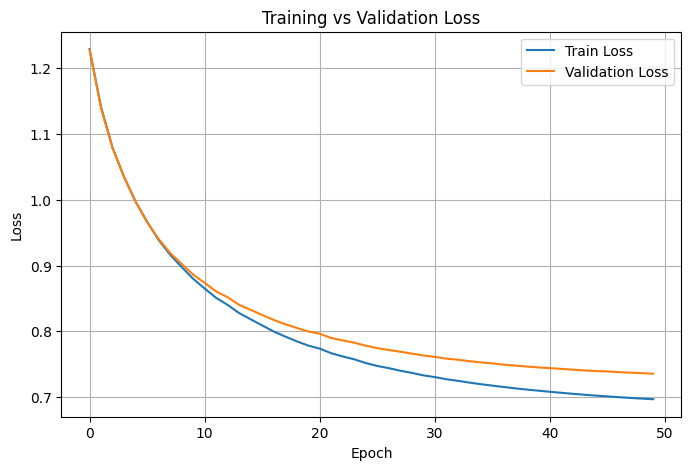

In [31]:
#Training Loss Graph
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

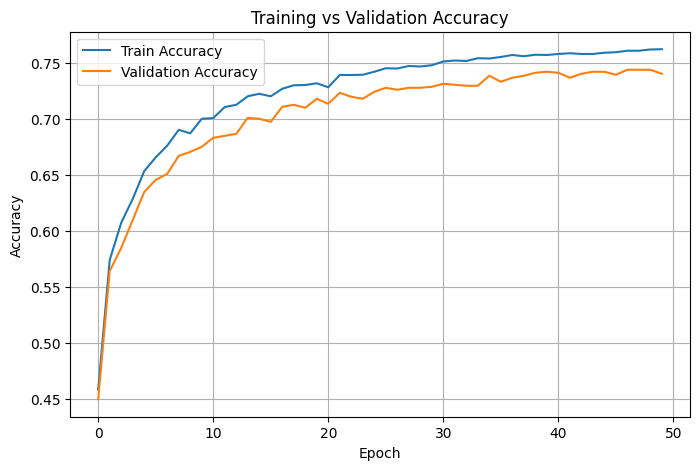

In [32]:
#Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")

plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
val_pred, _ = forward_propagation(
    X_val,
    params
)

y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(val_pred, axis=1)

print("Validation Prediction Shape:", val_pred.shape)

Validation Prediction Shape: (1120, 4)


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[191  91   8  10]
 [ 59 169  37  23]
 [  7   8 241   1]
 [  8  24  15 228]]


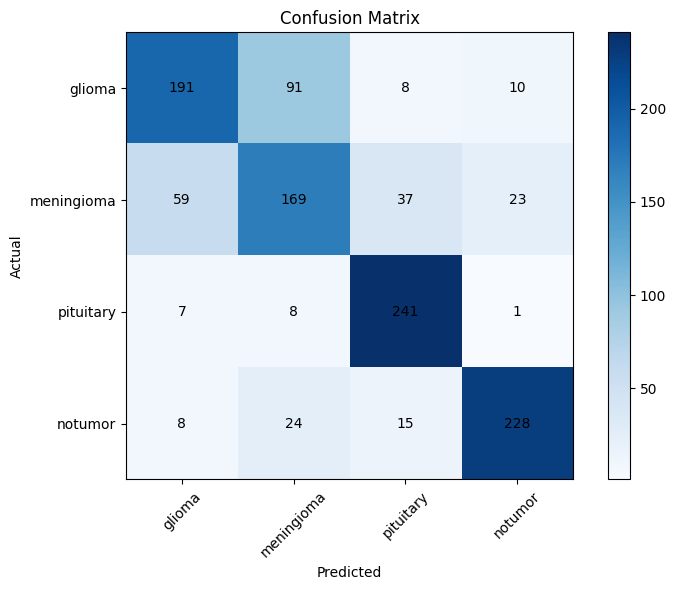

In [35]:
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(range(len(CLASSES)), CLASSES, rotation=45)
plt.yticks(range(len(CLASSES)), CLASSES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()

plt.show()

In [36]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      glioma       0.72      0.64      0.68       300
  meningioma       0.58      0.59      0.58       288
   pituitary       0.80      0.94      0.86       257
     notumor       0.87      0.83      0.85       275

    accuracy                           0.74      1120
   macro avg       0.74      0.75      0.74      1120
weighted avg       0.74      0.74      0.74      1120



In [37]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.7402
Precision : 0.7393
Recall    : 0.7402
F1 Score  : 0.7377


Total Misclassified Images: 291


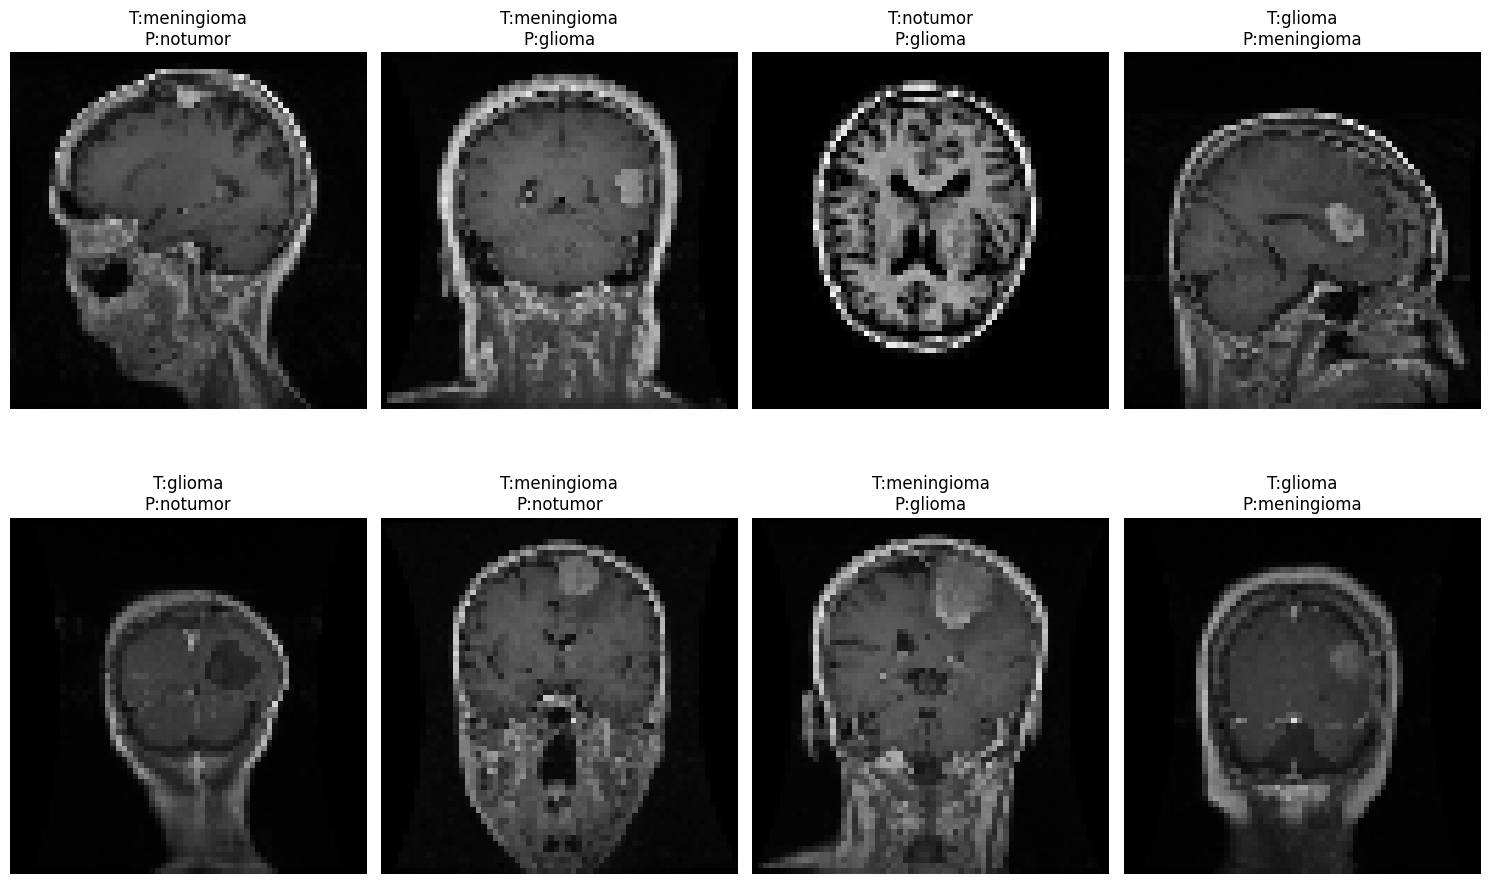

In [38]:
misclassified = np.where(y_true != y_pred)[0]

print("Total Misclassified Images:", len(misclassified))

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:8]):

    plt.subplot(2,4,i+1)

    plt.imshow(
        X_val[idx].reshape(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        )
    )

    plt.title(
        f"T:{CLASSES[y_true[idx]]}\nP:{CLASSES[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

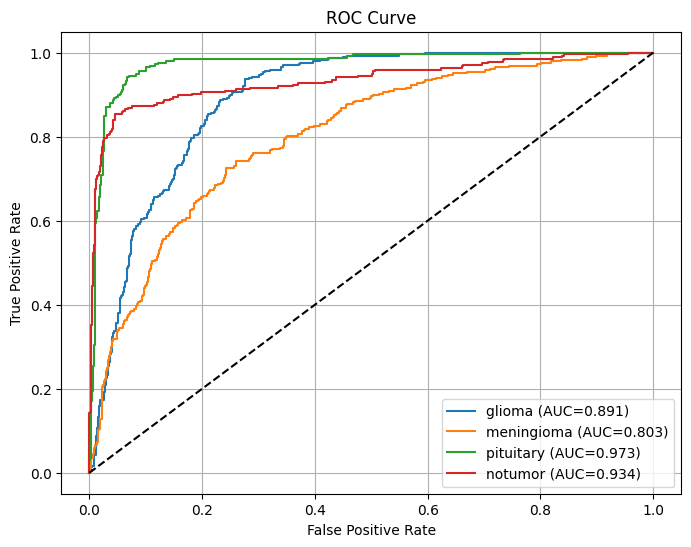

In [39]:
y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3]
)

plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        val_pred[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{CLASSES[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [40]:
with open(
    "NeuroVision_X_Model.pkl",
    "wb"
) as file:

    pickle.dump(
        params,
        file
    )

print("Model Saved Successfully")

Model Saved Successfully


In [41]:
with open(
    "NeuroVision_X_Model.pkl",
    "rb"
) as file:

    loaded_params = pickle.load(file)

print("Model Loaded Successfully")

Model Loaded Successfully


In [42]:
loaded_pred, _ = forward_propagation(
    X_test,
    loaded_params
)

loaded_acc = compute_accuracy(
    y_test,
    loaded_pred
)

print(f"Test Accuracy : {loaded_acc:.4f}")

Test Accuracy : 0.6769


# Project Summary

###**NeuroVision-X: Deep Artificial Neural Network From Scratch for Medical Image Classification**
### Dataset
Brain MRI Dataset

Classes:
- Glioma
- Meningioma
- Pituitary
- No Tumor



### Architecture
Input → 1024 → 512 → 256 → 4

### Activation Functions
- ReLU
- Softmax

### Optimizer
Mini-Batch Gradient Descent

### Loss Function
Cross Entropy Loss + L2 Regularization

### Advanced Features
- Learning Rate Decay
- Early Stopping
- Model Saving & Loading

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- Classification Report